# 09b_GAN_training_decay
**Variante con learning rate decay** rispetto a `09_GAN_training.ipynb` (che resta intatto, non sovrascritto). Nel primo training la FID migliorava fino a epoca 60 (314.77) poi oscillava senza piu' scendere per le restanti 90 epoche -- qui riduciamo lr_G/lr_D man mano che ci si avvicina a quel punto, per vedere se stabilizza il training oltre il plateau osservato.

Training completo del generatore GAN (allenamento lungo, non un breve trial come nel tuning), su Colab con GPU L4. Usa i learning rate scelti in `08_GAN_hyperparameter_tuning.ipynb`.

## Cosa produce
Solo i **pesi del generatore** allenato -- serviranno come prior generativo per il DPS (prossimo notebook, non ancora fatto). Il discriminatore serve solo qui, durante il training, poi si scarta.

## Checkpoint e ripresa
Salva un checkpoint completo su Drive ogni `CHECKPOINT_EVERY` epoche (generatore, discriminatore, entrambi gli ottimizzatori, numero di epoca) -- se il notebook si disconnette, rilancialo: riparte automaticamente dall'ultimo checkpoint invece che da zero.

## Prerequisito
`dataset_resized.zip` su Drive (serve solo `train_resized` qui; `validation_resized` e' usata per monitorare la FID durante il training, non per allenare).

In [ ]:
# DA ESEGUIRE SU COLAB PER GENERARE I PESI DELLA RETE GAN UTILIZZANDO METODO DECAY DOPO 60 ITER (SOLO EPR PROVA, MEGLIO LA VERSIONE NORMALE "GAN_training_new")

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DATASET_RESIZED_ZIP = "/content/drive/MyDrive/dataset_resized.zip"
LOCAL_DATASET_DIR = Path("/content/dataset_resized")

if not LOCAL_DATASET_DIR.exists():
    print("Estraggo dataset_resized...")
    get_ipython().system('unzip -q "{DATASET_RESIZED_ZIP}" -d /content/')
else:
    print("dataset_resized gia' estratto, salto.")

TRAIN_DIR = LOCAL_DATASET_DIR / "train_resized"
VALIDATION_DIR = LOCAL_DATASET_DIR / "validation_resized"

assert TRAIN_DIR.exists(), f"Non trovo {TRAIN_DIR}"
assert VALIDATION_DIR.exists(), f"Non trovo {VALIDATION_DIR}"

print(f"Immagini di train: {len(list(TRAIN_DIR.rglob('*.png')))}")

Mounted at /content/drive
Estraggo dataset_resized...
Immagini di train: 2733


In [ ]:
get_ipython().system('pip install -q torchmetrics[image]')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.4 MB/s eta 0:00:00


In [ ]:
import time
import json

import numpy as np
from skimage import io
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchmetrics.image.fid import FrechetInceptionDistance

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo in uso: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ============================================================
# Dataset (stesso caricamento usato nel tuning)
# ============================================================

def load_normalized_image(path: Path) -> np.ndarray:
    image = io.imread(path).astype(np.float32)
    max_value = np.iinfo(io.imread(path).dtype).max
    return image / max_value


class CTImageDataset(Dataset):
    def __init__(self, root_dir: Path):
        self.paths = sorted(root_dir.rglob("*.png"))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = load_normalized_image(self.paths[idx])
        return torch.from_numpy(image).float().unsqueeze(0)

In [ ]:
# ============================================================
# Architettura (identica a 08_GAN_hyperparameter_tuning.ipynb)
# ============================================================

class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=32):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 16), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 16, ngf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf // 2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf // 2, 1, 4, 2, 1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z.view(z.size(0), self.latent_dim, 1, 1))


class Discriminator(nn.Module):
    def __init__(self, ndf=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, ndf // 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf // 2, ndf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, ndf * 16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 16), nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 16, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
# ============================================================
# Configurazione -- learning rate presi dal tuning (fallback ai
# valori di default DCGAN se il file di tuning non e' disponibile)
# ============================================================

IMG_SIZE = 256
LATENT_DIM = 100
NGF = 32
NDF = 32

BATCH_SIZE = 32
FULL_EPOCHS = 150
CHECKPOINT_EVERY = 10
LABEL_SMOOTHING = 0.9
FID_N_SAMPLES = 300

TUNING_RESULT_PATH = Path("/content/drive/MyDrive/gan_tuning/best_gan_lr.json")

if TUNING_RESULT_PATH.exists():
    with open(TUNING_RESULT_PATH) as f:
        best = json.load(f)
    LR_G, LR_D = best["lr_g"], best["lr_d"]
    print(f"Learning rate di partenza presi dal tuning: lr_G={LR_G}, lr_D={LR_D} (FID={best['fid']:.2f})")
else:
    LR_G, LR_D = 2e-4, 2e-4
    print(f"File di tuning non trovato, uso i default DCGAN: lr_G={LR_G}, lr_D={LR_D}")

# ------------------------------------------------------------
# Learning rate decay: a partire da DECAY_START_EPOCH, lr_G e lr_D
# vengono moltiplicati per DECAY_GAMMA ogni DECAY_EVERY epoche.
# Con i valori di default: dimezzati a epoca 60, 90, 120, 150 --
# DECAY_START_EPOCH coincide con dove il primo training (senza decay)
# aveva smesso di migliorare (FID plateau/oscillazione da epoca 60).
# ------------------------------------------------------------
DECAY_START_EPOCH = 60
DECAY_EVERY = 30
DECAY_GAMMA = 0.5
print(f"Decay: dimezzamento di lr_G/lr_D ogni {DECAY_EVERY} epoche a partire da epoca {DECAY_START_EPOCH}")

train_dataset = CTImageDataset(TRAIN_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=2)
print(f"Immagini di train: {len(train_dataset)} -- {len(train_loader)} batch per epoca")

Learning rate di partenza presi dal tuning: lr_G=0.0002, lr_D=0.0002 (FID=385.09)
Decay: dimezzamento di lr_G/lr_D ogni 30 epoche a partire da epoca 60
Immagini di train: 2733 -- 85 batch per epoca


In [ ]:
# ============================================================
# Riferimento FID (immagini vere di validation) per monitorare il
# training senza mai toccare il test set
# ============================================================

def to_fid_input(x: torch.Tensor) -> torch.Tensor:
    return x.repeat(1, 3, 1, 1)


val_dataset = CTImageDataset(VALIDATION_DIR)
val_indices = np.random.RandomState(123).choice(len(val_dataset), size=min(FID_N_SAMPLES, len(val_dataset)), replace=False)
real_images = torch.stack([val_dataset[i] for i in val_indices])


def compute_fid(generator, n_samples=FID_N_SAMPLES, batch_size=32):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(DEVICE)
    for i in range(0, real_images.size(0), batch_size):
        batch = real_images[i:i + batch_size].to(DEVICE)
        fid.update(to_fid_input(batch), real=True)

    generator.eval()
    with torch.no_grad():
        for i in range(0, n_samples, batch_size):
            n = min(batch_size, n_samples - i)
            z = torch.randn(n, LATENT_DIM, device=DEVICE)
            fake = generator(z)
            fid.update(to_fid_input(fake), real=False)
    generator.train()

    return float(fid.compute())

In [ ]:
# ============================================================
# Setup del modello + RIPRESA da checkpoint se presente su Drive
# ============================================================

CHECKPOINT_DIR = Path("/content/drive/MyDrive/gan_checkpoints_decay")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "latest_checkpoint.pth"
SAMPLES_DIR = CHECKPOINT_DIR / "sample_grids"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

generator = Generator(LATENT_DIM, NGF).to(DEVICE)
discriminator = Discriminator(NDF).to(DEVICE)

opt_g = torch.optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

start_epoch = 0
history = {"g_loss": [], "d_loss": [], "fid": {}}
best_fid = float("inf")
BEST_WEIGHTS_PATH = CHECKPOINT_DIR / "generator_weights_best.pth"

if CHECKPOINT_PATH.exists():
    print(f"Checkpoint trovato, riprendo da: {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    generator.load_state_dict(ckpt["generator"])
    discriminator.load_state_dict(ckpt["discriminator"])
    opt_g.load_state_dict(ckpt["opt_g"])
    opt_d.load_state_dict(ckpt["opt_d"])
    start_epoch = ckpt["epoch"] + 1
    history = ckpt["history"]
    best_fid = ckpt.get("best_fid", float("inf"))   # .get per compatibilita' con checkpoint salvati prima di questa modifica
    print(f"Riparto dall'epoca {start_epoch}/{FULL_EPOCHS} -- miglior FID finora: {best_fid:.2f}" if best_fid != float("inf") else f"Riparto dall'epoca {start_epoch}/{FULL_EPOCHS}")
else:
    print("Nessun checkpoint trovato, parto da zero.")
    generator.apply(weights_init)
    discriminator.apply(weights_init)

Nessun checkpoint trovato, parto da zero.


In [ ]:
# ============================================================
# TRAINING -- salva checkpoint + griglia di campioni ogni
# CHECKPOINT_EVERY epoche, cosi' se il notebook si disconnette basta
# rilanciare questa cella per riprendere da dove si era arrivati.
# ============================================================

for epoch in range(start_epoch, FULL_EPOCHS):
    epoch_g_loss, epoch_d_loss = 0.0, 0.0

    for real in tqdm(train_loader, desc=f"Epoca {epoch + 1}/{FULL_EPOCHS}", leave=False):
        real = real.to(DEVICE)
        b = real.size(0)

        # --- Discriminatore ---
        opt_d.zero_grad()
        real_labels = torch.full((b,), LABEL_SMOOTHING, device=DEVICE)
        fake_labels = torch.zeros(b, device=DEVICE)

        loss_d_real = criterion(discriminator(real), real_labels)
        z = torch.randn(b, LATENT_DIM, device=DEVICE)
        fake = generator(z)
        loss_d_fake = criterion(discriminator(fake.detach()), fake_labels)
        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_d.step()

        # --- Generatore ---
        opt_g.zero_grad()
        loss_g = criterion(discriminator(fake), real_labels)
        loss_g.backward()
        opt_g.step()

        epoch_g_loss += loss_g.item()
        epoch_d_loss += loss_d.item()

    avg_g = epoch_g_loss / len(train_loader)
    avg_d = epoch_d_loss / len(train_loader)
    history["g_loss"].append(avg_g)
    history["d_loss"].append(avg_d)
    print(f"Epoca {epoch + 1}/{FULL_EPOCHS} -- loss_G: {avg_g:.4f}  loss_D: {avg_d:.4f}")

    # Decay del learning rate, se siamo a un'epoca di decay
    if (epoch + 1) >= DECAY_START_EPOCH and (epoch + 1 - DECAY_START_EPOCH) % DECAY_EVERY == 0:
        for pg in opt_g.param_groups:
            pg["lr"] *= DECAY_GAMMA
        for pg in opt_d.param_groups:
            pg["lr"] *= DECAY_GAMMA
        print(f"  Learning rate ridotti: lr_G={opt_g.param_groups[0]['lr']:.6f}  lr_D={opt_d.param_groups[0]['lr']:.6f}")

    is_checkpoint_epoch = (epoch + 1) % CHECKPOINT_EVERY == 0
    is_last_epoch = (epoch + 1) == FULL_EPOCHS

    if is_checkpoint_epoch or is_last_epoch:
        fid_score = compute_fid(generator)
        history["fid"][str(epoch + 1)] = fid_score
        print(f"  FID a epoca {epoch + 1}: {fid_score:.2f}")

        generator.eval()
        with torch.no_grad():
            z = torch.randn(9, LATENT_DIM, device=DEVICE)
            samples = generator(z).cpu().numpy()
        generator.train()

        fig, axs = plt.subplots(3, 3, figsize=(9, 9))
        for ax, img in zip(axs.flat, samples):
            ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
        plt.suptitle(f"Epoca {epoch + 1} -- FID={fid_score:.2f}")
        plt.tight_layout()
        plt.savefig(SAMPLES_DIR / f"epoch_{epoch + 1:04d}.png", dpi=120)
        plt.close(fig)

        # Salva i pesi del generatore SOLO se questa e' la FID migliore vista finora
        # -- a differenza del checkpoint "ultima epoca", questo file non viene mai
        # sovrascritto da un risultato peggiore (il training GAN puo' degenerare
        # dopo aver raggiunto un buon punto, quindi "ultimo" non e' sempre "migliore").
        if fid_score < best_fid:
            best_fid = fid_score
            torch.save(generator.state_dict(), BEST_WEIGHTS_PATH)
            print(f"  Nuovo miglior FID ({best_fid:.2f}) -- pesi salvati in generator_weights_best.pth")

        torch.save({
            "epoch": epoch,
            "generator": generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "opt_g": opt_g.state_dict(),
            "opt_d": opt_d.state_dict(),
            "history": history,
            "best_fid": best_fid,
        }, CHECKPOINT_PATH)
        print(f"  Checkpoint salvato (epoca {epoch + 1}).")

print("\nTraining completato.")

Epoca 1/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 1/150 -- loss_G: 9.3380  loss_D: 0.4917


Epoca 2/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 2/150 -- loss_G: 9.5356  loss_D: 0.5902


Epoca 3/150:   0%|          | 0/85 [00:00<?, ?it/s]

...

Epoca 148/150 -- loss_G: 6.7568  loss_D: 0.3300


Epoca 149/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 149/150 -- loss_G: 6.6026  loss_D: 0.3310


Epoca 150/150:   0%|          | 0/85 [00:00<?, ?it/s]

Epoca 150/150 -- loss_G: 6.8624  loss_D: 0.3296
  Learning rate ridotti: lr_G=0.000013  lr_D=0.000013
  FID a epoca 150: 349.81
  Checkpoint salvato (epoca 150).

Training completato.


In [ ]:
# ============================================================
# Salvataggio finale: solo i pesi del generatore (quello che servira'
# per il DPS), separato dal checkpoint completo di training.
# ============================================================

# generator_weights_best.pth e' gia' stato salvato durante il training (ogni
# volta che la FID migliorava) -- qui solo un riepilogo, nessun file nuovo da
# salvare (non teniamo un file separato per "l'ultima epoca": non serve al
# resto della pipeline, e i pesi dell'ultima epoca sono comunque gia' dentro
# latest_checkpoint.pth se mai volessi controllarli).
print(f"Pesi con la FID migliore ({best_fid:.2f}) salvati in: {BEST_WEIGHTS_PATH}")
print("Per il DPS, carica questo file -- e' l'unico pezzo che ti serve da qui in poi.")

Pesi con la FID migliore (331.96) salvati in: /content/drive/MyDrive/gan_checkpoints_decay/generator_weights_best.pth
Per il DPS, carica questo file -- e' l'unico pezzo che ti serve da qui in poi.


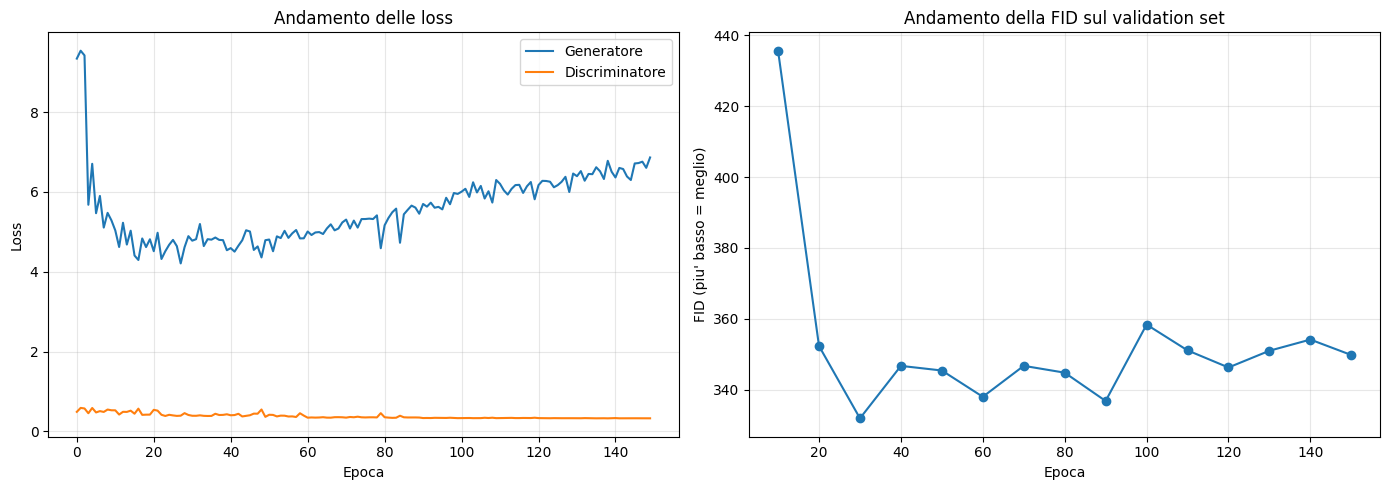

In [ ]:
# ============================================================
# Andamento di loss e FID durante tutto il training
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history["g_loss"], label="Generatore")
axs[0].plot(history["d_loss"], label="Discriminatore")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Loss")
axs[0].set_title("Andamento delle loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

fid_epochs = sorted(int(e) for e in history["fid"].keys())
fid_values = [history["fid"][str(e)] for e in fid_epochs]
axs[1].plot(fid_epochs, fid_values, marker="o")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("FID (piu' basso = meglio)")
axs[1].set_title("Andamento della FID sul validation set")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "training_curves.png", dpi=150)
plt.show()

## Prossimo passo
I pesi in `gan_checkpoints_decay/generator_weights_best.pth` (quelli con la FID migliore osservata durante il training, non necessariamente l'ultima epoca) sono pronti per essere caricati nel notebook DPS (da fare dopo), che li usera' come prior generativo dentro il ciclo di campionamento guidato dai sinogrammi di test.